# Deep Learning Capstone: Your Own CNN Experiments

In the previous CNN tutorial, you learned the building blocks. Now it's **your turn to experiment!**

This notebook is different: it's not a step-by-step tutorial. Instead, you'll:
1. Get a dataset and baseline CNN
2. Train and evaluate it (quick iteration)
3. **Diagnose** what's wrong (underfitting? overfitting?)
4. **Fix it** by trying different techniques
5. Repeat until you're satisfied!

## Learning Objectives

By the end of this session, you will be able to:
- Set up a complete CNN training pipeline independently
- **Diagnose** model problems from learning curves
- **Apply** targeted fixes (architecture, regularization, augmentation)
- **Iterate** quickly to improve performance
- Make evidence-based decisions about what to try next

<div class="alert alert-block alert-success">
<b>💡 THE LEARNING CYCLE</b>

Modern deep learning is about **fast iteration**:
1. Train quickly (a few epochs)
2. Look at curves (underfit? overfit? good?)
3. Change ONE thing
4. Repeat

Don't try to build the perfect model on the first try!
</div>

## 0. Setup

Same PyTorch stack as before. We've kept this section short so you can focus on experiments.

In [ ]:
import os
import ssl
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Optional SSL/cert fix
cert_path = Path.home() / "certificates" / "combined_cert.pem"
if cert_path.exists():
    os.environ["SSL_CERT_FILE"] = str(cert_path)
    os.environ["REQUESTS_CA_BUNDLE"] = str(cert_path)
    ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=str(cert_path))

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

# Paths and device
project_root = Path("..").resolve()
data_dir = project_root / "data"
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"✓ Setup complete")
print(f"✓ Device: {device}")
print(f"✓ PyTorch: {torch.__version__}")

Device: mps
torch: 2.10.0
torchvision: 0.25.0


## 1. Load Dataset

We'll try CIFAR-100 first (100 classes, harder), with fallback to CIFAR-10 if download fails.

**Why CIFAR-100?** 
- More challenging than CIFAR-10 (similar classes: leopard vs jaguar)
- Small enough to train quickly
- Tests whether your CNN generalizes well

<div class="alert alert-block alert-info">
<b>BEFORE RUNNING: PREDICT</b>

- CIFAR-10 achieves ~70-90% with simple CNNs
- CIFAR-100 is much harder: ~40-70% is typical
- What accuracy do you expect from a random baseline?
  - CIFAR-10: ~10% (1/10 classes)
  - CIFAR-100: ~1% (1/100 classes)
</div>

In [ ]:
# Dataset configuration
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

def try_load_cifar100(data_dir, transform):
    try:
        train_data = datasets.CIFAR100(root=data_dir, train=True, download=True, transform=transform)
        test_data = datasets.CIFAR100(root=data_dir, train=False, download=True, transform=transform)
        return train_data, test_data, "CIFAR-100", False
    except Exception as e:
        print(f"⚠️ CIFAR-100 failed: {e}")
        return None, None, None, True

def try_load_cifar10(data_dir, transform):
    try:
        train_data = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
        test_data = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
        return train_data, test_data, "CIFAR-10", False
    except Exception as e:
        print(f"⚠️ CIFAR-10 download failed: {e}")
        return None, None, None, True

def load_fallback_npz(npz_path):
    """Small local fallback for offline use"""
    data = np.load(npz_path)
    x_train = torch.tensor(data["x_train"], dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    y_train = torch.tensor(data["y_train"], dtype=torch.long)
    x_test = torch.tensor(data["x_test"], dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    y_test = torch.tensor(data["y_test"], dtype=torch.long)
    
    # Apply normalization
    mean_t = torch.tensor(mean).view(1, 3, 1, 1)
    std_t = torch.tensor(std).view(1, 3, 1, 1)
    x_train = (x_train - mean_t) / std_t
    x_test = (x_test - mean_t) / std_t
    
    return TensorDataset(x_train, y_train), TensorDataset(x_test, y_test), "CIFAR-10 (fallback)", False

# Try loading in order: CIFAR-100 → CIFAR-10 → fallback
train_dataset, test_dataset, dataset_name, failed = try_load_cifar100(data_dir, train_transform)

if failed:
    train_dataset, test_dataset, dataset_name, failed = try_load_cifar10(data_dir, train_transform)

if failed:
    train_dataset, test_dataset, dataset_name, _ = load_fallback_npz(data_dir / "cifar10_fallback.npz")

# Get class info
if hasattr(train_dataset, "classes"):
    class_names = list(train_dataset.classes)
else:
    class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

num_classes = len(class_names)

print(f"✓ Loaded: {dataset_name}")
print(f"  • Training: {len(train_dataset)} samples")
print(f"  • Test: {len(test_dataset)} samples")
print(f"  • Classes: {num_classes}")
print(f"  • Example classes: {class_names[:5]}")

100.0%

/Users/jolan.heyse/Library/CloudStorage/OneDrive-VIB/Documents/Course Material/machine-learning-and-deep-learning-fundamentals/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
/Users/jolan.heyse/Library/CloudStorage/OneDrive-VIB/Documents/Course Material/machine-learning-and-deep-learning-fundamentals/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Fallback used: False
#classes: 100
Train size: 50000 | Test size: 10000
Example class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']


### Quick Data Exploration

Let's verify the dataset is balanced and visualize some samples.

Min class count: 500
Max class count: 500


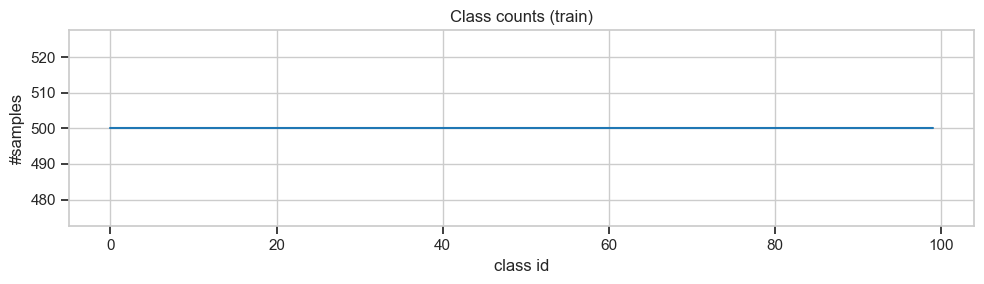

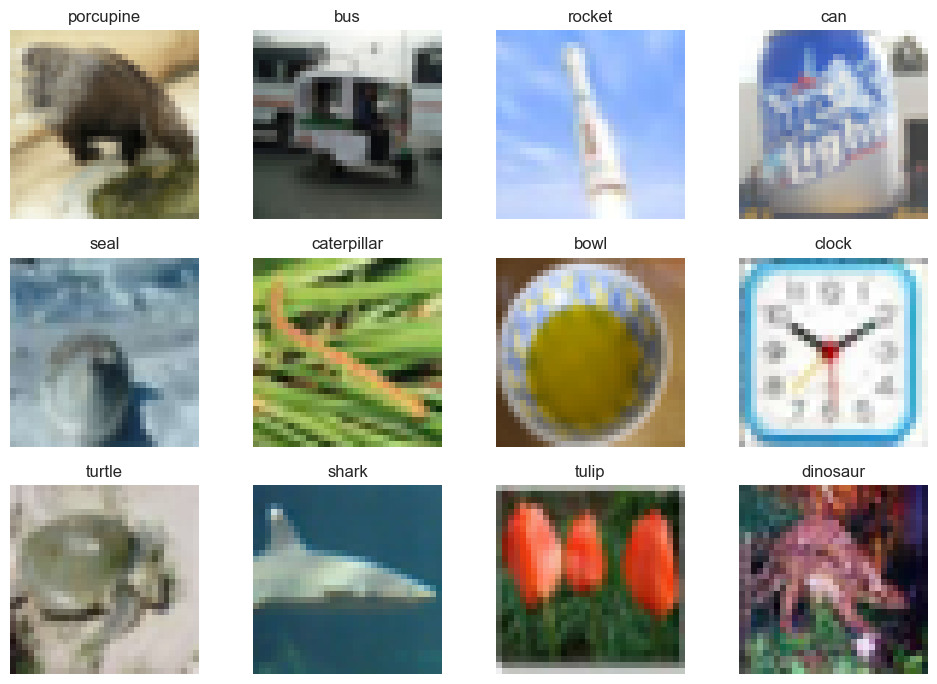

In [ ]:
def denormalize(tensor, mean, std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return tensor * std_t + mean_t

def show_batch(dataset, class_names, n=12):
    indices = np.random.choice(len(dataset), size=n, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(10, 7))
    for ax, idx in zip(axes.flatten(), indices):
        image, label = dataset[idx]
        if isinstance(image, torch.Tensor):
            image = denormalize(image, mean, std).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(image)
        ax.set_title(class_names[int(label)], fontsize=9)
        ax.axis("off")
    plt.suptitle(f"Random {dataset_name} Samples", fontsize=12, y=0.98)
    plt.tight_layout()
    plt.show()

# Check class balance
def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return torch.tensor(dataset.targets, dtype=torch.long)
    if isinstance(dataset, TensorDataset):
        return dataset.tensors[1]
    raise TypeError("Cannot extract targets")

targets = get_targets(train_dataset)
counts = torch.bincount(targets, minlength=num_classes)

print(f"📊 Class Balance:")
print(f"  • Min samples/class: {int(counts.min())}")
print(f"  • Max samples/class: {int(counts.max())}")
print(f"  • {'✓ Balanced!' if counts.max() - counts.min() < 10 else '⚠️ Imbalanced'}")

# Show samples
show_batch(train_dataset, class_names, n=12)

### Create DataLoaders

Split into train/val and create efficient mini-batch loaders.

In [ ]:
# Train/val split
val_size = 5000 if len(train_dataset) > 5000 else max(10, len(train_dataset) // 5)
train_size = len(train_dataset) - val_size

train_ds, val_ds = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"✓ DataLoaders ready:")
print(f"  • Train: {len(train_ds)} samples ({len(train_loader)} batches)")
print(f"  • Val: {len(val_ds)} samples ({len(val_loader)} batches)")
print(f"  • Test: {len(test_dataset)} samples ({len(test_loader)} batches)")
print(f"  • Batch size: {batch_size}")

# Quick sanity check
xb, yb = next(iter(train_loader))
print(f"\n✓ Batch check:")
print(f"  • Input shape: {tuple(xb.shape)} (batch, channels, height, width)")
print(f"  • Label range: {int(yb.min())} to {int(yb.max())} (expected: 0 to {num_classes-1})")

(45000, 5000, 10000)

## 2. Training Utilities (Your Toolbox)

These functions are your tools for this session. **You don't need to modify them** - just use them!

Read through once to understand what they do, then focus on experiments.

In [ ]:
def accuracy_from_logits(logits, targets):
    """Compute accuracy from raw model outputs"""
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

def evaluate_loader(model, loader, criterion, device):
    """Evaluate model on a dataset"""
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_items = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model(inputs)
            loss = criterion(logits, targets)
            
            batch_size = inputs.size(0)
            total_loss += loss.item() * batch_size
            total_acc += accuracy_from_logits(logits, targets) * batch_size
            total_items += batch_size
    
    return total_loss / total_items, total_acc / total_items

def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    """Train model and return history"""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        running_loss = 0.0
        running_acc = 0.0
        total_items = 0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            
            batch_size = inputs.size(0)
            running_loss += loss.item() * batch_size
            running_acc += accuracy_from_logits(logits, targets) * batch_size
            total_items += batch_size
        
        train_loss = running_loss / total_items
        train_acc = running_acc / total_items
        val_loss, val_acc = evaluate_loader(model, val_loader, criterion, device)
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train_loss={train_loss:.3f} train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")
    
    return history

def plot_history(history):
    """Plot learning curves"""
    epochs_axis = np.arange(1, len(history["train_loss"]) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(epochs_axis, history["train_loss"], label="Train", linewidth=2)
    axes[0].plot(epochs_axis, history["val_loss"], label="Val", linewidth=2, linestyle="--")
    axes[0].set_title("Loss Over Time", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Accuracy
    axes[1].plot(epochs_axis, history["train_acc"], label="Train", linewidth=2)
    axes[1].plot(epochs_axis, history["val_acc"], label="Val", linewidth=2, linestyle="--")
    axes[1].set_title("Accuracy Over Time", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def show_misclassifications(dataset, model, class_names, device, n=12):
    """Show random misclassified examples"""
    model.eval()
    indices = np.random.permutation(len(dataset))
    wrong = []
    
    with torch.no_grad():
        for idx in indices:
            if len(wrong) >= n:
                break
            image, label = dataset[int(idx)]
            if not isinstance(image, torch.Tensor):
                continue
            logits = model(image.unsqueeze(0).to(device))
            pred = torch.argmax(logits, dim=1).item()
            if int(pred) != int(label):
                wrong.append((image.cpu(), int(label), int(pred)))
    
    if len(wrong) == 0:
        print("✓ No misclassifications found in sample! (Try re-running or increase n)")
        return
    
    fig, axes = plt.subplots(3, 4, figsize=(10, 7))
    for ax, (image, y_true, y_pred) in zip(axes.flatten(), wrong):
        img = denormalize(image, mean, std).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(f"True: {class_names[y_true]}\nPred: {class_names[y_pred]}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Misclassified Examples", fontsize=12, y=0.98)
    plt.tight_layout()
    plt.show()

print("✓ Training utilities loaded")

## 3. Your CNN Architecture

Here's a simple baseline CNN to start with. This is **your playground** - modify it as you experiment!

**Architecture overview:**
```
Input: 32×32×3
  ↓ Conv 32 → ReLU → MaxPool → 16×16×32
  ↓ Conv 64 → ReLU → MaxPool → 8×8×64
  ↓ Conv 128 → ReLU → MaxPool → 4×4×128
  ↓ Flatten → Dense 256 → ReLU → Dropout → Dense num_classes
Output: Class scores
```

<div class="alert alert-block alert-info">
<b>EXPERIMENT IDEAS</b>

**To reduce overfitting:**
- Add BatchNorm2d after Conv layers
- Increase Dropout rate
- Reduce model size (fewer filters)

**To reduce underfitting:**
- Add more Conv blocks
- Increase filter counts (32→64→128→256)
- Remove/reduce Dropout
- Train longer

**Architecture tricks:**
- Try 3×3 kernels everywhere (standard)
- Try stride=2 instead of MaxPool
- Try residual connections (advanced)
</div>

In [ ]:
class StudentCNN(nn.Module):
    """Baseline CNN - modify this as you experiment!"""
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            # Block 1: 32×32 → 16×16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2: 16×16 → 8×8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3: 8×8 → 4×4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Initialize model
model = StudentCNN(num_classes=num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())

print(model)
print(f"\n📊 Model stats:")
print(f"  • Total parameters: {total_params:,}")
print(f"  • Device: {device}")

StudentCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=100, bias=True)
  )
)

## 4. First Training Run: Establish Baseline

Let's do a **quick training run** (just 5 epochs) to see how the baseline performs.

**What to watch for:**
- Starting accuracy (should be near random: ~1% for CIFAR-100, ~10% for CIFAR-10)
- Learning happening? (loss decreasing, accuracy increasing)
- Overfitting signs? (train >> val accuracy)
- Underfitting signs? (both train and val accuracy low)

<div class="alert alert-block alert-warning">
<b>⏱️ QUICK ITERATION STRATEGY</b>

Train for just **3-5 epochs** per experiment:
- See trends quickly
- Try more ideas in less time
- Only train longer once you found something promising

This is how professionals work: fast iteration!
</div>

In [ ]:
# Training configuration
epochs = 5  # Keep short for fast iteration!
lr = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print(f"🚀 Starting training ({epochs} epochs)...\n")
history = fit(model, train_loader, val_loader, criterion, optimizer, device, epochs)

print(f"\n✓ Training complete!")
plot_history(history)

### Diagnose Your Model

Now look at the curves and answer these questions:

<div class="alert alert-block alert-info">
<b>DIAGNOSTIC QUESTIONS</b>

1. **Is it learning?**
   - Is loss decreasing over epochs?
   - Is accuracy increasing?

2. **Overfitting or underfitting?**
   - **Overfitting**: Train acc >> Val acc (gap > 10%)
     - Fix: Add regularization (Dropout, BatchNorm, augmentation)
   - **Underfitting**: Both train and val acc are low
     - Fix: Bigger model, train longer, lower regularization
   - **Good fit**: Train ≈ Val, both improving

3. **What should you try next?**
   - Write down your hypothesis before changing anything!
</div>

💡 **Your diagnosis**: _(write it down before continuing!)_

## 5. Evaluate on Test Set

Now test on held-out data. This is your "honest" performance estimate.

In [ ]:
test_loss, test_acc = evaluate_loader(model, test_loader, criterion, device)

print(f"📊 Test Results:")
print(f"  • Loss: {test_loss:.3f}")
print(f"  • Accuracy: {test_acc*100:.2f}%")

# Compare to validation
val_final = history["val_acc"][-1]
diff = abs(test_acc - val_final)
if diff < 0.02:
    print(f"  • ✓ Good! Test ≈ Val (diff: {diff*100:.1f}%)")
else:
    print(f"  • ⚠️ Gap between test and val: {diff*100:.1f}%")

# Show some mistakes
show_misclassifications(test_dataset, model, class_names, device, n=12)

### Confusion Analysis (for CIFAR-10 only)

For CIFAR-100 (100 classes), confusion matrices are too large. We'll just show top confusions.

In [ ]:
# Collect predictions
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        logits = model(inputs)
        preds = torch.argmax(logits, dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(targets.cpu())

y_true = torch.cat(all_targets)
y_pred = torch.cat(all_preds)

# Show confusion matrix for CIFAR-10, or top confusions for CIFAR-100
if num_classes <= 20:
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true.numpy(), y_pred.numpy(),
        display_labels=class_names,
        xticks_rotation=45,
        cmap="Blues"
    )
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.tight_layout()
    plt.show()
else:
    # Compute top confusions
    cm = torch.zeros((num_classes, num_classes), dtype=torch.long)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    
    # Get off-diagonal (errors only)
    off_diag = cm.clone()
    off_diag.fill_diagonal_(0)
    
    flat = off_diag.flatten()
    top_vals, top_idx = torch.topk(flat, k=min(10, flat.numel()))
    
    print("📊 Top 10 Confusions (True → Predicted):")
    print("=" * 60)
    for v, idx in zip(top_vals.tolist(), top_idx.tolist()):
        if v == 0:
            break
        i = idx // num_classes
        j = idx % num_classes
        print(f"  {class_names[i]:20s} → {class_names[j]:20s} : {v:3d} times")

---
## 6. Experimental Tools

Below are tools you can use to improve your model. **Pick ONE at a time** and see what happens!

### Tool 1: Data Augmentation

The single most effective technique for image classification. Apply random transformations during training.

In [ ]:
# Data augmentation (training only!)
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # Random shift
    transforms.RandomHorizontalFlip(),     # Flip 50% of time
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# To use this:
# 1. Reload dataset with train_transform_aug
# 2. Recreate DataLoaders
# 3. Train a new model

print("✓ Augmentation transforms ready")
print("\n💡 To apply:")
print("   1. Reload dataset with train_transform_aug")
print("   2. Recreate train_loader")
print("   3. Train new model and compare curves")

### Tool 2: Stronger Regularization

Try these if you're **overfitting** (train >> val accuracy).

In [ ]:
# Option A: Weight decay (L2 regularization)
optimizer_wd = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)

# Option B: Label smoothing (softer targets)
criterion_ls = nn.CrossEntropyLoss(label_smoothing=0.1)

print("✓ Regularization options ready:")
print("  • optimizer_wd: Adam with weight decay")
print("  • criterion_ls: CrossEntropy with label smoothing")
print("\n💡 Use these instead of `optimizer` and `criterion` in fit()")

### Tool 3: Learning Rate Scheduling

If training plateaus, try reducing learning rate over time.

In [ ]:
# Reduce LR when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, verbose=True
)

print("✓ Scheduler ready")
print("\n💡 To use: After each epoch, call:")
print("   scheduler.step(val_loss)")
print("   (You'll need to modify the fit() loop)")

---
## 7. Your Experiment Log

**Document your experiments here!** Copy/paste this template for each experiment:

```
=== EXPERIMENT N ===
Hypothesis: [What do you think will happen?]
Changes: [What did you change from previous run?]

Results:
- Train acc: X%
- Val acc: X%
- Test acc: X%

Observations: [What happened? Match your hypothesis?]
Next step: [What will you try next?]
```

**Example:**
```
=== EXPERIMENT 1 (Baseline) ===
Hypothesis: Will underfit (model too small for CIFAR-100)
Changes: None (first run)

Results:
- Train acc: 35%
- Val acc: 28%
- Test acc: 27%

Observations: Gap between train/val suggests slight overfitting. But both are low, so also underfitting.
Next step: Try data augmentation first (always good for vision).
```

---
# 📝 START YOUR LOG HERE:



---
## 8. Experiment Template

Use this cell for quick experiments. Copy it if you need more!

In [ ]:
# ==================================================
# EXPERIMENT: [Give it a name]
# ==================================================
# Hypothesis: [What do you expect?]
# Changes: [What's different?]

# 1. Define model
# model = StudentCNN(num_classes=num_classes).to(device)

# 2. Define training setup
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# epochs = 5

# 3. Train
# history = fit(model, train_loader, val_loader, criterion, optimizer, device, epochs)
# plot_history(history)

# 4. Evaluate
# test_loss, test_acc = evaluate_loader(model, test_loader, criterion, device)
# print(f"Test accuracy: {test_acc*100:.2f}%")

# 5. Analyze mistakes (optional)
# show_misclassifications(test_dataset, model, class_names, device)

# ==================================================
# RESULTS:
# - Train acc: 
# - Val acc:
# - Test acc:
# 
# OBSERVATIONS:
# [What did you learn?]
# ==================================================

## Summary and Reflection

By now you should have run 3-5 experiments. Reflect on what you learned:

<div class="alert alert-block alert-success">
<b>🎯 REFLECTION QUESTIONS</b>

1. **What worked best for improving validation accuracy?**
   - Data augmentation? Bigger model? Regularization?

2. **What surprised you?**
   - Did something work better/worse than expected?

3. **How would you continue if you had more time?**
   - More epochs? Different architecture? Better augmentation?

4. **What did you learn about the diagnosis → fix cycle?**
   - Can you quickly identify overfitting vs underfitting?
   - Do you know which tools to reach for?

**Write your answers:**
- 
- 
- 
</div>

### Key Takeaways

✅ **Fast iteration** beats perfect planning  
✅ **Learning curves** tell you what to do next  
✅ **Change one thing** at a time to understand impact  
✅ **Data augmentation** almost always helps for vision  
✅ **Experimentation** is how you learn deep learning  

**You're now ready for real-world CNN projects!** 🎉